In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline

import seaborn as sns


import os, sys, shutil, importlib, glob
from tqdm.notebook import tqdm
# from celloracle import motif_analysis as ma
# import celloracle as co
import scanpy as sc


In [2]:
df_dar = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv")

In [3]:
df_dar

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Subclass,Sex,Region Subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100456562-100457063,-0.006031,Down,Glut,chr10:100456562-100457063,2.751694e-02
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112328.1,chr10:100642797-100643298,-0.014478,Down,Glut,chr10:100642797-100643298,1.490774e-02
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112713.1,chr10:10107158-10107659,0.030881,Up,Glut,chr10:10107158-10107659,2.347109e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000018909.15,chr7:99535252-99535753,0.001785,Up,GABA,chr7:99535252-99535753,1.977464e-02
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032803.15,chr9:103365644-103366145,0.028069,Up,GABA,chr9:103365644-103366145,4.904168e-02
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032470.17,chr9:99436435-99436936,-0.054067,Down,GABA,chr9:99436435-99436936,3.488255e-02
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,PFC_Sst_Chodl_GABA,M,PFC_Sst_Chodl_GABA,ENSMUSG00000021368.15,chr13:43171217-43171718,NaN,Down,GABA,chr13:43171217-43171718,1.842970e-02


In [4]:
df_full = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE.peak_gene_corr.sig.csv')

In [5]:
df_dar_merge = df_dar.merge(df_full, left_on=['names'], right_on=['peak_id'], how='left',suffixes=('_dar', '_corr'))

In [6]:
df_dar_merge['ctname'] = df_dar_merge['ctname'].str.replace('.',"-")
#df_dar_merge = df_dar_merge[df_dar_merge['ctname'].str.contains('GABA|Glut', na=False)].copy()

In [7]:
df_deg_all = pd.read_excel("/data2st2/junyi/output/1-1 six_dataset_DEG_list_fdr_FC01_filtered_7region_rmMB 20251227.xlsx",sheet_name="all",index_col=0)
df_deg_CU3RM = df_deg_all[df_deg_all['Model'].str.contains('CUSUS M')].copy()
df_deg_CU3RM = df_deg_CU3RM[df_deg_CU3RM['Region'].isin(['AMY','HPF','PFC'])].copy()
df_deg_CU3RM['ctname'] = df_deg_CU3RM['Region'] + "_" + df_deg_CU3RM['Subclass']
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('/', '-')
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace(' ', '_')
df_deg_CU3RM['targetgene'] = df_deg_CU3RM.index

In [8]:
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('HPF_HPF_',"HPF_")
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('PFC_PFC_',"PFC_")
df_deg_CU3RM['ctname'] = df_deg_CU3RM['ctname'].str.replace('AMY_AMY_',"AMY_")
#df_deg_CU3RM = df_deg_CU3RM[df_deg_CU3RM['ctname'].str.contains('GABA|Glut', na=False)].copy()

In [9]:
df_deg_CU3RM

,pval,log2FC,ci.hi,ci.lo,FDR,Bonferroni,Subclass,Region,Sex,Method,...,log2FC_Wilcoxon,pval_Wilcoxon,FDR_Wilcoxon,pct_nz_group,comparison_group,Bonferroni_Wilcoxon,Subclass_Wilcoxon,Model,ctname,targetgene
Gene,,,,,,,,,,,,,,,,,,,,,
4930402H24Rik,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.182837,8.127867e-04,4.171538e-02,0.835152,SUS,1.000000e+00,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930402H24Rik
4930544I03Rik,8.507894e-17,0.246177,0.303235,0.189119,2.114743e-14,3.383589e-13,Astrocyte-2,PFC,M,MAST,...,0.784293,6.880562e-16,7.486510e-13,0.363010,SUS,1.122976e-11,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930544I03Rik
4930570B17Rik,1.128117e-06,-0.162081,-0.098318,-0.225843,4.824216e-05,4.486521e-03,Astrocyte-2,PFC,M,MAST,...,-0.410762,1.254829e-06,2.027729e-04,0.412407,SUS,2.048006e-02,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930570B17Rik
4932438H23Rik,3.780038e-10,0.110726,0.144643,0.076810,3.956108e-08,1.503321e-06,Astrocyte-2,PFC,M,MAST,...,0.994446,5.201400e-10,2.358113e-07,0.139001,SUS,8.489205e-06,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4932438H23Rik
9330182L06Rik,9.458295e-09,0.131010,0.176086,0.085934,7.233776e-07,3.761564e-05,Astrocyte-2,PFC,M,MAST,...,0.638395,9.022050e-08,2.265367e-05,0.228030,SUS,1.472489e-03,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,9330182L06Rik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ugdh,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,0.413112,1.056860e-05,4.248527e-04,0.362975,SUS,1.724902e-01,OPC,CUSUS M,AMY_OPC,Ugdh
Vegfa,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,-0.849232,4.784782e-08,4.514014e-06,0.147092,SUS,7.809243e-04,OPC,CUSUS M,AMY_OPC,Vegfa
Wscd1,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,0.354396,1.179816e-04,2.727166e-03,0.284676,SUS,1.000000e+00,OPC,CUSUS M,AMY_OPC,Wscd1


In [10]:
df_deg_merged = df_deg_CU3RM.merge(df_dar_merge, left_on=['targetgene','ctname','Direction'], right_on=['gene_name_dar','ctname','Direction'], how='left', suffixes=('_deg', '_dar'))

In [11]:
df_deg_merged_corr = df_deg_CU3RM.merge(df_dar_merge, left_on=['targetgene','ctname','Direction'], right_on=['gene_name_corr','ctname','Direction'], how='left', suffixes=('_deg', '_dar'))

In [12]:
df_deg_merged_corr

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,log2FC_dar,Neurotransmitter_dar,Gene_name_dar,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.011184,NN,chr2:130664048-130664549,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.000070,147.0,0.000967
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.011184,NN,chr2:130664048-130664549,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.000070,147.0,0.000967
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.000730,NN,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.000730,NN,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.034135,NN,chr2:131204550-131205051,0.006046,chr2:131204550-131205051,4930402H24Rik,-0.210634,0.010443,147.0,0.045913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31820,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31821,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31822,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31823,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df_deg_explained = df_deg_merged.dropna(subset=['gene_name_dar'])
num_df_degexplained = df_deg_explained.drop_duplicates(subset=['targetgene','ctname','Direction']).shape[0]

In [14]:
len(df_deg_explained)

17847

In [15]:
df_deg_CU3RM['nlogp'] = -1*np.log(df_deg_CU3RM['FDR']) * np.sign(df_deg_CU3RM['log2FC'])

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [16]:
df_deg_CU3RM

,pval,log2FC,ci.hi,ci.lo,FDR,Bonferroni,Subclass,Region,Sex,Method,...,pval_Wilcoxon,FDR_Wilcoxon,pct_nz_group,comparison_group,Bonferroni_Wilcoxon,Subclass_Wilcoxon,Model,ctname,targetgene,nlogp
Gene,,,,,,,,,,,,,,,,,,,,,
4930402H24Rik,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,8.127867e-04,4.171538e-02,0.835152,SUS,1.000000e+00,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930402H24Rik,4.623055
4930544I03Rik,8.507894e-17,0.246177,0.303235,0.189119,2.114743e-14,3.383589e-13,Astrocyte-2,PFC,M,MAST,...,6.880562e-16,7.486510e-13,0.363010,SUS,1.122976e-11,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930544I03Rik,31.487258
4930570B17Rik,1.128117e-06,-0.162081,-0.098318,-0.225843,4.824216e-05,4.486521e-03,Astrocyte-2,PFC,M,MAST,...,1.254829e-06,2.027729e-04,0.412407,SUS,2.048006e-02,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4930570B17Rik,-9.939277
4932438H23Rik,3.780038e-10,0.110726,0.144643,0.076810,3.956108e-08,1.503321e-06,Astrocyte-2,PFC,M,MAST,...,5.201400e-10,2.358113e-07,0.139001,SUS,8.489205e-06,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,4932438H23Rik,17.045420
9330182L06Rik,9.458295e-09,0.131010,0.176086,0.085934,7.233776e-07,3.761564e-05,Astrocyte-2,PFC,M,MAST,...,9.022050e-08,2.265367e-05,0.228030,SUS,1.472489e-03,Astrocyte-2,CUSUS M,PFC_Astrocyte-2,9330182L06Rik,14.139334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ugdh,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,1.056860e-05,4.248527e-04,0.362975,SUS,1.724902e-01,OPC,CUSUS M,AMY_OPC,Ugdh,7.628035
Vegfa,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,4.784782e-08,4.514014e-06,0.147092,SUS,7.809243e-04,OPC,CUSUS M,AMY_OPC,Vegfa,-24.521813
Wscd1,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,1.179816e-04,2.727166e-03,0.284676,SUS,1.000000e+00,OPC,CUSUS M,AMY_OPC,Wscd1,10.003678


In [17]:
df_dar_merge['nlogp'] = -1*np.log(df_dar_merge['FDR_dar'])  * np.sign(df_dar_merge['log2FC'])

In [18]:
shared_absmax = max(
    df_deg_CU3RM['log2FC'].abs().max(),
    df_dar_merge['log2FC'].abs().max()
 )
shared_absmax = 1 if pd.isna(shared_absmax) or shared_absmax == 0 else shared_absmax

df_deg_CU3RM['nlogp_scaled'] = df_deg_CU3RM['nlogp'] / df_deg_CU3RM['nlogp'].abs().max()
df_dar_merge['nlogp_scaled'] = df_dar_merge['nlogp'] / df_dar_merge['nlogp'].abs().max()

In [19]:
df_dar_merge['nlogp_scaled'] 

0        -0.011287
1        -0.011287
2         0.050674
3         0.050674
4        -0.013212
            ...   
883097   -0.010542
883098         NaN
883099         NaN
883100         NaN
883101         NaN
Name: nlogp_scaled, Length: 883102, dtype: float64

In [20]:
def plot_deg_dar_heatmap(
    df_deg,
    df_dar,
    dar_index_col='gene_name_dar',
    deg_index_col='targetgene',
    value_col='nlogp',
    ctname_col='ctname',
    coef_threshold=0.01,
    ctname_filter='GABA|Glut',
    deg_vmin=-50, deg_vmax=50,
    dar_vmin=-25, dar_vmax=25,
    title='Gene-level DEG and DAR Heatmaps',
    return_matrices=False,
):
    """
    Plot side-by-side heatmaps of DEG and DAR nlogp values, clustered by DAR.

    Parameters
    ----------
    df_deg : DataFrame
        DEG data (e.g. df_deg_CU3RM). Must contain deg_index_col, ctname_col, value_col.
    df_dar : DataFrame
        DAR data with coef column (e.g. df_dar_merge). Must contain dar_index_col, ctname_col, value_col.
    dar_index_col : str
        Column in df_dar to use as pivot index (e.g. 'gene_name_dar', 'gene_name_corr').
    deg_index_col : str
        Column in df_deg to use as pivot index (default 'targetgene').
    value_col : str
        Column for pivot values (default 'nlogp').
    ctname_col : str
        Column for pivot columns (default 'ctname').
    coef_threshold : float
        Filter df_dar to |coef| > threshold (default 0.01).
    ctname_filter : str or None
        Regex to filter ctname values (e.g. 'GABA|Glut'). If None, keep all.
    deg_vmin, deg_vmax : float
        Heatmap color range for DEG.
    dar_vmin, dar_vmax : float
        Heatmap color range for DAR.
    title : str
        Suptitle for the figure.
    return_matrices : bool
        If True, return (fig, deg_matrix, dar_matrix) instead of showing.

    Returns
    -------
    fig, deg_matrix, dar_matrix (optional)
    """
    # --- DEG pivot ---
    deg_matrix = df_deg.pivot_table(
        index=deg_index_col, columns=ctname_col,
        values=value_col, aggfunc='median', fill_value=0
    )

    # --- DAR pivot ---
    df_dar_filt = df_dar[np.abs(df_dar['coef']) > coef_threshold] if coef_threshold is not None else df_dar
    dar_matrix = df_dar_filt.pivot_table(
        index=dar_index_col, columns=ctname_col,
        values=value_col, aggfunc='median', fill_value=0
    )

    # --- shared genes & ctnames ---
    shared_genes = deg_matrix.index.intersection(dar_matrix.index)
    shared_ctnames = deg_matrix.columns.intersection(dar_matrix.columns)
    if ctname_filter is not None:
        shared_ctnames = shared_ctnames[shared_ctnames.str.contains(ctname_filter, na=False)]

    deg_matrix = deg_matrix.loc[shared_genes, shared_ctnames]
    dar_matrix = dar_matrix.loc[shared_genes, shared_ctnames]

    col_order = sorted(shared_ctnames)
    deg_matrix = deg_matrix.loc[:, col_order]
    dar_matrix = dar_matrix.loc[:, col_order]

    deg_matrix = deg_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)
    dar_matrix = dar_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)

    # --- clustering on DAR ---
    n_genes = len(shared_genes)
    clust = sns.clustermap(
        dar_matrix, cmap='coolwarm', center=0,
        vmin=-1, vmax=1, row_cluster=True, col_cluster=False,
        figsize=(6, min(10, n_genes * 0.12))
    )
    row_order = deg_matrix.index[clust.dendrogram_row.reordered_ind]
    plt.close(clust.fig)

    deg_matrix = deg_matrix.loc[row_order]
    dar_matrix = dar_matrix.loc[row_order]

    # --- plot ---
    fig, axes = plt.subplots(
        1, 2, figsize=(16, min(10, n_genes * 0.12)), sharey=True
    )
    sns.heatmap(deg_matrix, cmap='coolwarm', center=0,
                ax=axes[0], vmin=deg_vmin, vmax=deg_vmax, cbar=True)
    sns.heatmap(dar_matrix, cmap='coolwarm', center=0,
                ax=axes[1], vmin=dar_vmin, vmax=dar_vmax, cbar=True)

    axes[0].set_title('DEG nlogp')
    axes[1].set_title('DAR nlogp')
    axes[0].set_xlabel(ctname_col)
    axes[1].set_xlabel(ctname_col)
    axes[0].set_ylabel('gene')
    axes[1].set_ylabel('')
    axes[0].set_xticks(np.arange(len(col_order)) + 0.5)
    axes[1].set_xticks(np.arange(len(col_order)) + 0.5)
    axes[0].set_xticklabels(col_order, rotation=90)
    axes[1].set_xticklabels(col_order, rotation=90)
    plt.suptitle(title, y=1.02)
    plt.tight_layout()

    if return_matrices:
        return fig, deg_matrix, dar_matrix
    plt.show()

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


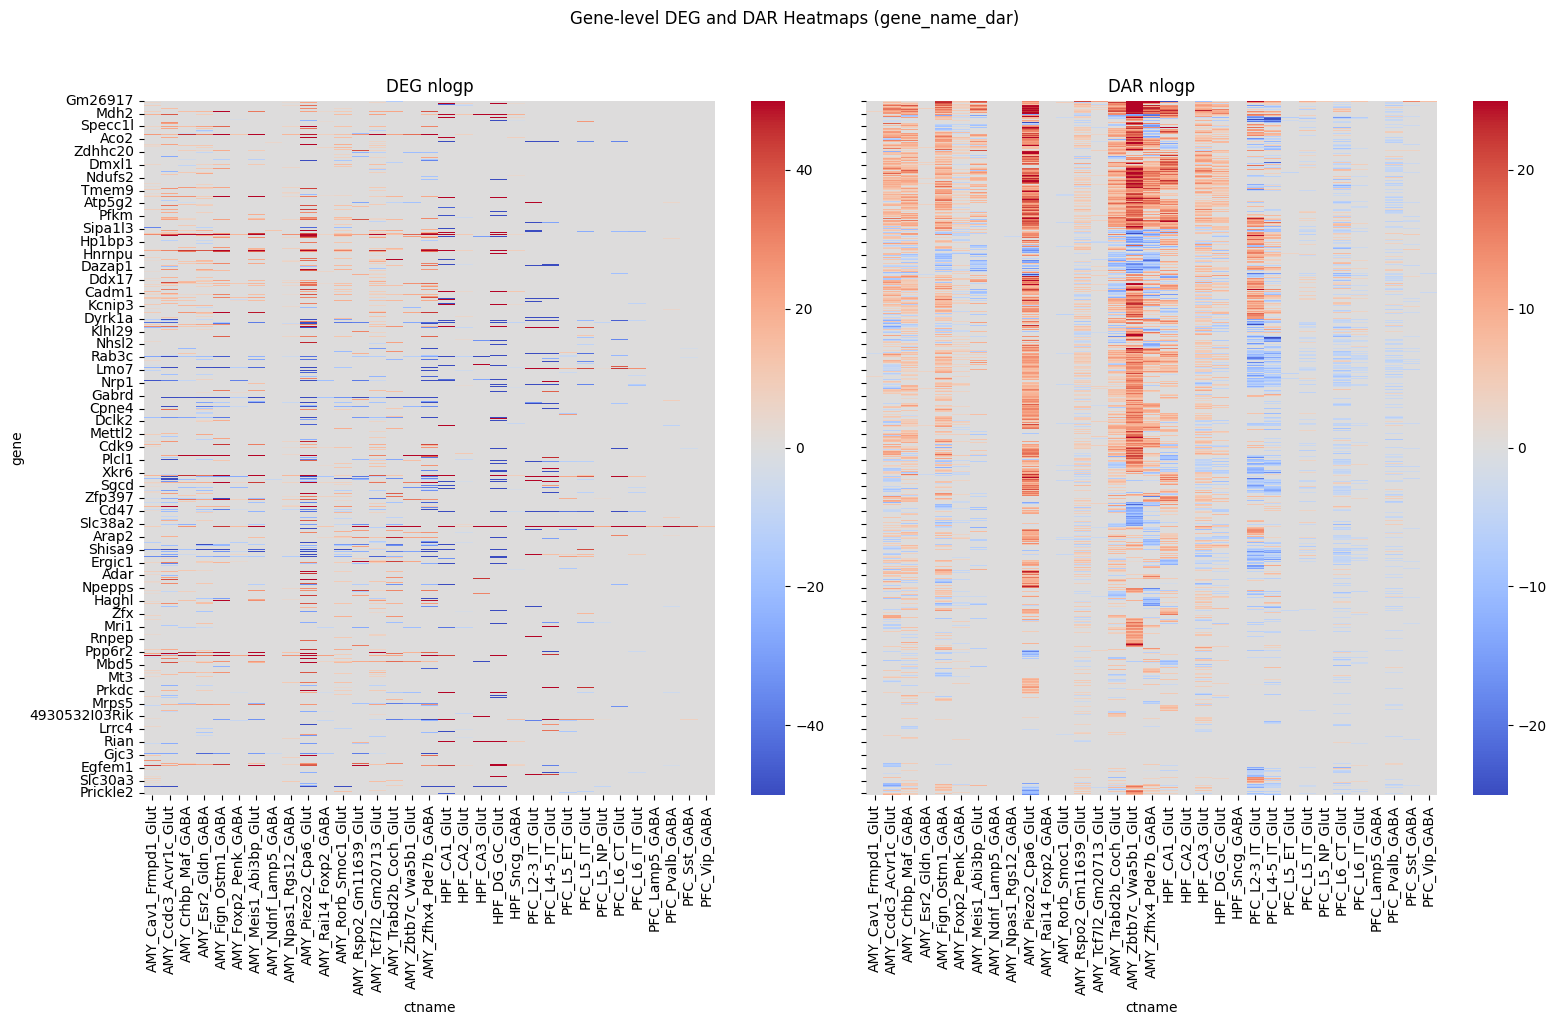

In [21]:
plot_deg_dar_heatmap(
    df_deg=df_deg_CU3RM,
    df_dar=df_dar_merge,
    dar_index_col='gene_name_dar',
    title='Gene-level DEG and DAR Heatmaps (gene_name_dar)',
)

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


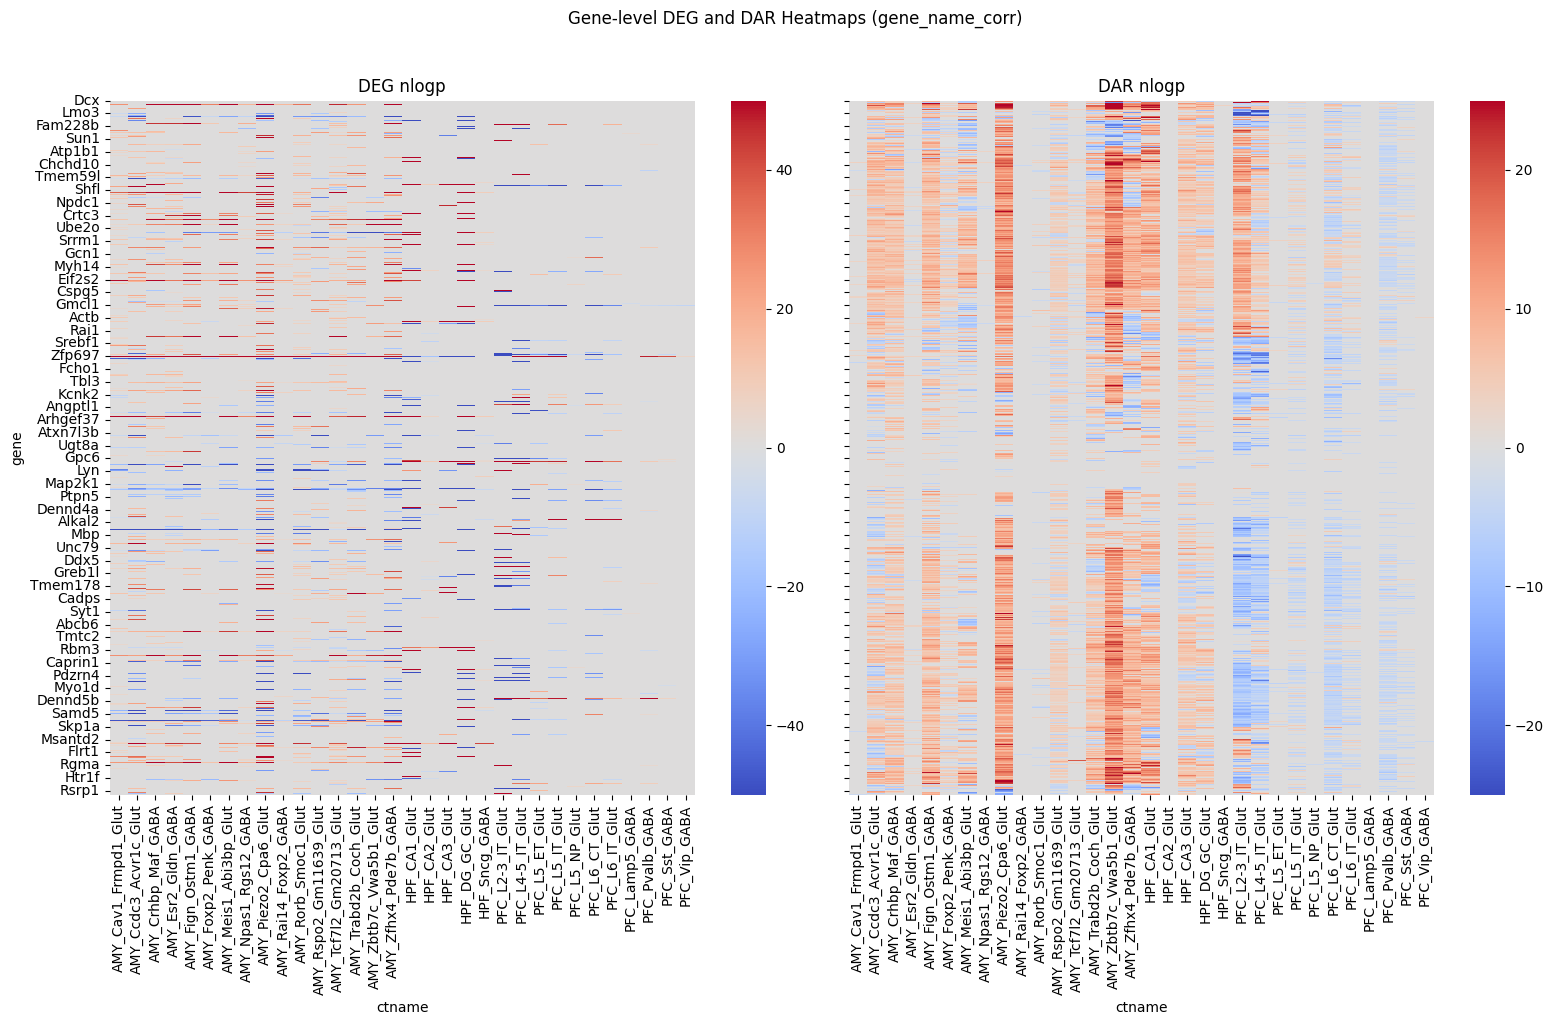

In [22]:
plot_deg_dar_heatmap(
    df_deg=df_deg_CU3RM,
    df_dar=df_dar_merge,
    dar_index_col='gene_name_corr',
    title='Gene-level DEG and DAR Heatmaps (gene_name_corr)',
)

In [23]:
df_deg_merged

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,log2FC_dar,Neurotransmitter_dar,Gene_name_dar,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.00073,NN,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.00073,NN,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,Rnf24,0.214794,0.008986,147.0,0.041158
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.00073,NN,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.00073,NN,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,Rnf24,0.214794,0.008986,147.0,0.041158
4,8.507894e-17,0.246177,0.303235,0.189119,2.114743e-14,3.383589e-13,Astrocyte-2,PFC,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30499,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30500,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30501,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30502,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df_deg_merged_corr['has_DAR'] = ~df_deg_merged_corr['gene_name_corr'].isna()   
df_deg_merged_corr['region'] = df_deg_merged_corr['ctname'].str.split('_').str[0]
df_deg_merged_corr['Region_NT'] = df_deg_merged_corr['region']+"_"+df_deg_merged_corr['Neurotransmitter_deg']

In [25]:
def plot_dar_support_barplot(
    df_merged,
    dar_col='gene_name_corr',
    gene_col='targetgene',
    ctname_col='ctname',
    comp_col='Model',
    region_nt_col='Region_NT',
    neurotransmitter_col='Neurotransmitter_deg',
    comp_order=None,
    figsize_width_per_bar=0.35,
    figsize_height=7,
    title='DEGs with / without DAR support, by Region_NT and comparison',
    return_data=False,
):
    """
    Plot stacked barplot of DEGs with / without DAR support,
    grouped by Region_NT and comparison model.

    Parameters
    ----------
    df_merged : DataFrame
        Merged DEG-DAR dataframe. Must contain dar_col, gene_col, ctname_col, comp_col.
    dar_col : str
        Column name to check for DAR support (non-NaN = Match, NaN = Mismatch).
    gene_col : str
        Column name for gene identifier (used for deduplication).
    ctname_col : str
        Column name for cell-type name (e.g. 'AMY_GABA').
    comp_col : str
        Column name for comparison/model (e.g. 'Model').
    region_nt_col : str
        Column name for region+neurotransmitter grouping.
        If not present in df_merged, will be created from ctname_col and neurotransmitter_col.
    neurotransmitter_col : str
        Column name for neurotransmitter info (used to build Region_NT if missing).
    comp_order : list or None
        Preferred order of comparison models. If None, uses a default order.
    figsize_width_per_bar : float
        Width multiplier per bar group.
    figsize_height : float
        Figure height.
    title : str
        Plot title.
    return_data : bool
        If True, return (fig, summary_df) instead of showing.

    Returns
    -------
    fig, summary_df (optional)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd

    df = df_merged.copy()

    # --- compute has_DAR ---
    df['has_DAR'] = ~df[dar_col].isna()

    # --- compute region / Region_NT if needed ---
    if region_nt_col not in df.columns:
        df['region'] = df[ctname_col].str.split('_').str[0]
        df[region_nt_col] = df['region'] + '_' + df[neurotransmitter_col]
    region_col = region_nt_col

    # --- clean Model column ---
    df[comp_col] = df[comp_col].astype(str).str.replace(' ', '_', regex=False)

    # --- match_status & Direction ---
    df['match_status'] = np.where(df['has_DAR'], 'Match', 'Mismatch')
    df['Direction'] = df['Direction'].astype(str).str.capitalize()
    df = df[df['Direction'].isin(['Up', 'Down'])].copy()

    # --- count unique DEGs per group ---
    summary_df = (
        df.groupby([region_col, comp_col, 'Direction', 'match_status'], as_index=False)
        .agg(count=(gene_col, 'nunique'))
    )

    # --- region order ---
    region_order = sorted(
        summary_df[region_col].drop_duplicates().tolist(),
        key=lambda x: (
            ['AMY', 'HPF', 'PFC'].index(x.split('_')[0])
            if x.split('_')[0] in ['AMY', 'HPF', 'PFC'] else 99,
            x.split('_')[1]
        )
    )

    if comp_order is None:
        comp_order = ['CUSUS_F', 'CURES_F', 'CUSUS_M', 'CURES_M', 'CSSUS_M', 'CSRES_M']

    # --- build x positions ---
    x_positions = {}
    tick_positions = []
    tick_labels = []
    current_x = 0
    gap_between_regions = 0.3

    for rnt in region_order:
        present = summary_df.loc[summary_df[region_col] == rnt, comp_col].drop_duplicates().tolist()
        ordered = [c for c in comp_order if c in present]
        ordered += [c for c in present if c not in ordered]
        if not ordered:
            continue
        for comp in ordered:
            x_positions[(rnt, comp)] = current_x
            tick_positions.append(current_x)
            tick_labels.append(rnt)
            current_x += 1
        current_x += gap_between_regions

    # --- pivot to wide format ---
    plot_wide = (
        summary_df.pivot_table(
            index=[region_col, comp_col],
            columns=['Direction', 'match_status'],
            values='count',
            fill_value=0
        )
        .reindex(list(x_positions.keys()), fill_value=0)
    )

    for col_combo in [('Up', 'Match'), ('Up', 'Mismatch'), ('Down', 'Match'), ('Down', 'Mismatch')]:
        if col_combo not in plot_wide.columns:
            plot_wide[col_combo] = 0

    plot_wide = plot_wide[[('Up', 'Match'), ('Up', 'Mismatch'), ('Down', 'Match'), ('Down', 'Mismatch')]]

    x_vals = [x_positions[idx] for idx in plot_wide.index]
    up_match = plot_wide[('Up', 'Match')].to_numpy()
    up_mismatch = plot_wide[('Up', 'Mismatch')].to_numpy()
    down_match = -plot_wide[('Down', 'Match')].to_numpy()
    down_mismatch = -plot_wide[('Down', 'Mismatch')].to_numpy()

    # --- colors ---
    colors = {
        'up_match': '#b2182b',
        'up_mismatch': '#f4a582',
        'down_match': '#2166ac',
        'down_mismatch': '#92c5de',
    }

    # --- plot ---
    fig, ax = plt.subplots(figsize=(max(10, len(x_vals) * figsize_width_per_bar), figsize_height))

    ax.bar(x_vals, up_match, color=colors['up_match'], label='Up + DAR (Match)')
    ax.bar(x_vals, up_mismatch, bottom=up_match, color=colors['up_mismatch'], label='Up no DAR (Mismatch)')
    ax.bar(x_vals, down_match, color=colors['down_match'], label='Down + DAR (Match)')
    ax.bar(x_vals, down_mismatch, bottom=down_match, color=colors['down_mismatch'], label='Down no DAR (Mismatch)')

    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('DEG count', fontsize=11)
    ax.set_title(title, fontsize=12)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors['up_match'], label='Up + DAR (Match)'),
        plt.Rectangle((0, 0), 1, 1, color=colors['up_mismatch'], label='Up no DAR (Mismatch)'),
        plt.Rectangle((0, 0), 1, 1, color=colors['down_match'], label='Down + DAR (Match)'),
        plt.Rectangle((0, 0), 1, 1, color=colors['down_mismatch'], label='Down no DAR (Mismatch)'),
    ]
    ax.legend(handles=legend_handles, frameon=False, ncol=2, loc='upper right')
    sns.despine(ax=ax, left=False, bottom=False)
    plt.tight_layout()

    if return_data:
        return fig, summary_df.sort_values([region_col, comp_col, 'Direction', 'match_status']).reset_index(drop=True)
    plt.show()

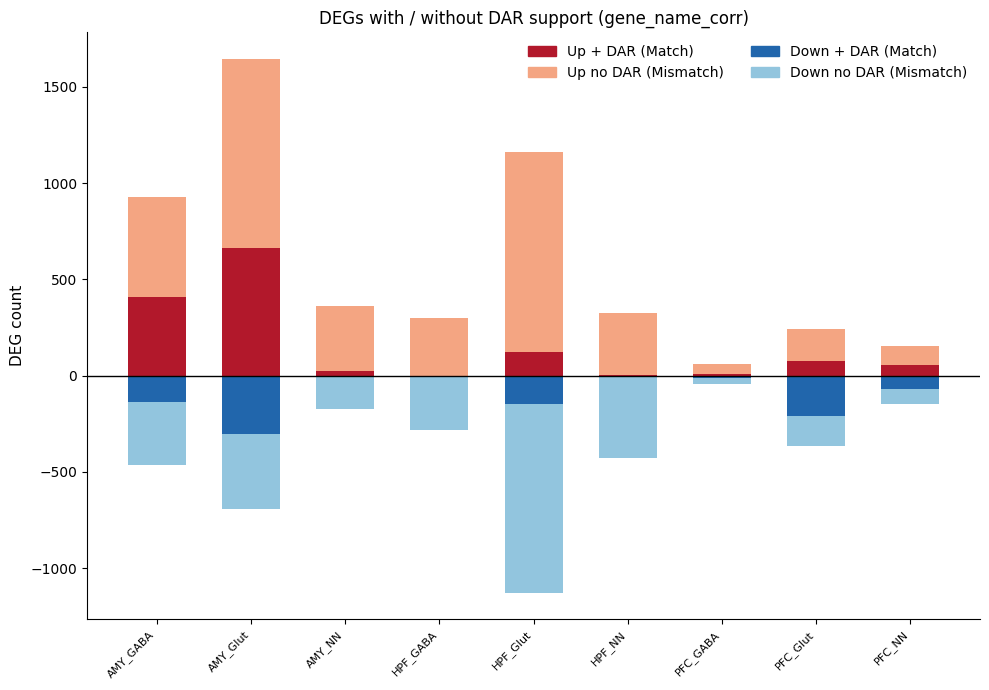

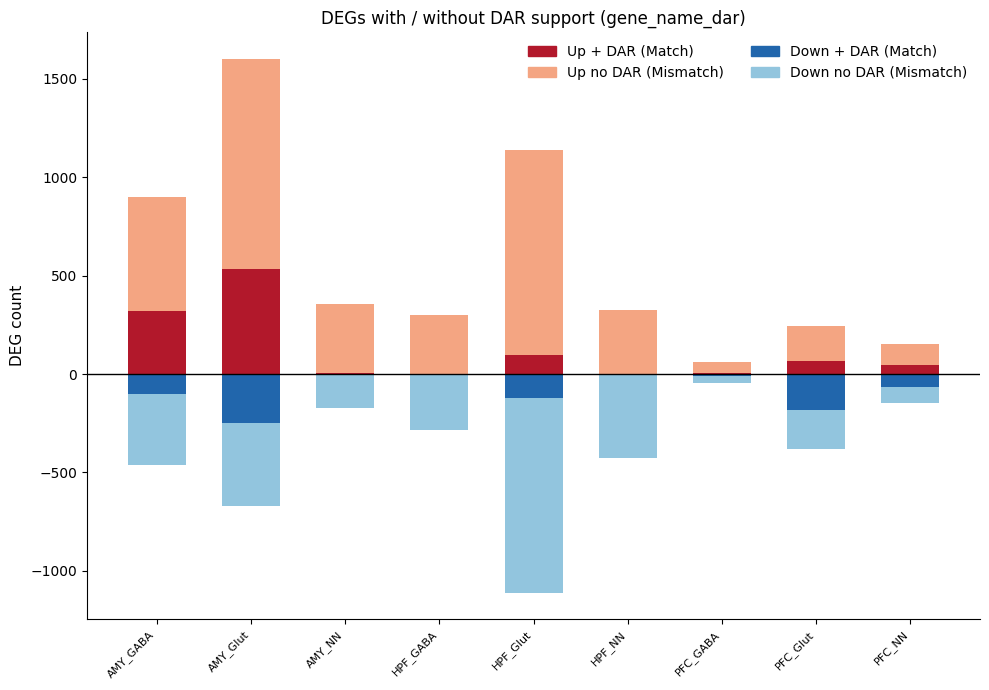

In [26]:
# ── 用 gene_name_corr 判断 has_DAR ──
plot_dar_support_barplot(
    df_merged=df_deg_merged_corr,
    dar_col='gene_name_corr',
    title='DEGs with / without DAR support (gene_name_corr)',
)

# ── 用 gene_name_dar 判断 has_DAR ──
plot_dar_support_barplot(
    df_merged=df_deg_merged,
    dar_col='gene_name_dar',
    title='DEGs with / without DAR support (gene_name_dar)',
)

In [27]:
df_dar_merge

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Gene_name,FDR_dar,peak_id,gene_name_corr,correlation,pval,n_samples,FDR_corr,nlogp,nlogp_scaled
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,chr10:100456562-100457063,2.751694e-02,chr10:100456562-100457063,Kitl,0.266765,0.001090,147.0,0.008463,-3.592954,-0.011287
1,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,chr10:100456562-100457063,2.751694e-02,chr10:100456562-100457063,4930430F08Rik,0.221632,0.006979,147.0,0.034212,-3.592954,-0.011287
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,chr10:100487209-100487710,9.867574e-08,chr10:100487209-100487710,Cep290,0.225227,0.006093,147.0,0.030957,16.131427,0.050674
3,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,chr10:100487209-100487710,9.867574e-08,chr10:100487209-100487710,Cep290,0.225227,0.006093,147.0,0.030957,16.131427,0.050674
4,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,chr10:100642797-100643298,1.490774e-02,NaN,NaN,NaN,NaN,NaN,NaN,-4.205875,-0.013212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883097,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,chr9:99436435-99436936,3.488255e-02,NaN,NaN,NaN,NaN,NaN,NaN,-3.355768,-0.010542
883098,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,chr13:43171217-43171718,1.842970e-02,chr13:43171217-43171718,Gfod1,0.354556,0.000011,147.0,0.000207,NaN,NaN
883099,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,chr13:43171217-43171718,1.842970e-02,chr13:43171217-43171718,Ranbp9,0.269241,0.000975,147.0,0.007765,NaN,NaN
883100,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,chr13:43171217-43171718,1.842970e-02,chr13:43171217-43171718,Gfod1,0.354556,0.000011,147.0,0.000207,NaN,NaN


In [28]:
df_motif_match = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/motif_match.csv', index_col=0)

In [29]:
df_motif_match

,MA0004.1.Arnt,MA0069.1.PAX6,MA0071.1.RORA,MA0074.1.RXRA::VDR,MA0101.1.REL,MA0107.1.RELA,MA0111.1.Spz1,MA0115.1.NR1H2::RXRA,MA0119.1.NFIC::TLX1,MA0130.1.ZNF354C,...,MA0116.2.ZNF423,MA2484.1.Dmrtb1,MA2485.1.Duxbl1,MA2486.1.Fosb,MA1540.3.Nr5a1,MA0505.3.Nr5a2,MA0506.3.Nrf1,MA1618.2.Ptf1A,MA0002.3.Runx1,MA2503.1.Banp
chr,,,,,,,,,,,,,,,,,,,,,
chr1-3003518-3004019,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
chr1-3007481-3007982,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr1-3012480-3012981,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
chr1-3013424-3013925,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr1-3014717-3015218,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrY-90812660-90813161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chrY-90811433-90811934,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chrY-90813596-90814097,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# # ── 列名只保留 . 后的部分 ──
# df_motif_match.columns = df_motif_match.columns.str.split('.').str[-1]
# df_motif_match

In [31]:
df_motif_match

,MA0004.1.Arnt,MA0069.1.PAX6,MA0071.1.RORA,MA0074.1.RXRA::VDR,MA0101.1.REL,MA0107.1.RELA,MA0111.1.Spz1,MA0115.1.NR1H2::RXRA,MA0119.1.NFIC::TLX1,MA0130.1.ZNF354C,...,MA0116.2.ZNF423,MA2484.1.Dmrtb1,MA2485.1.Duxbl1,MA2486.1.Fosb,MA1540.3.Nr5a1,MA0505.3.Nr5a2,MA0506.3.Nrf1,MA1618.2.Ptf1A,MA0002.3.Runx1,MA2503.1.Banp
chr,,,,,,,,,,,,,,,,,,,,,
chr1-3003518-3004019,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
chr1-3007481-3007982,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr1-3012480-3012981,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
chr1-3013424-3013925,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr1-3014717-3015218,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrY-90812660-90813161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chrY-90811433-90811934,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chrY-90813596-90814097,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
# ── 将 motif 矩阵 (0/1) 压缩为 region → 逗号分隔的 motif 名 ──
df_motif_long = (
    df_motif_match
    .apply(lambda row: ','.join(row.index[row == 1].tolist()), axis=1)
    .reset_index()
    .rename(columns={'index': 'region_id', 0: 'motif_genes'})
)
# 过滤掉没有 motif 匹配的行
df_motif_long = df_motif_long[df_motif_long['motif_genes'] != ''].copy()

df_motif_long

,chr,motif_genes
0,chr1-3003518-3004019,"MA0130.1.ZNF354C,MA0599.1.KLF5,MA0741.1.KLF16,..."
1,chr1-3007481-3007982,"MA0101.1.REL,MA0107.1.RELA,MA0660.1.MEF2B,MA00..."
2,chr1-3012480-3012981,"MA0142.1.Pou5f1::Sox2,MA0151.1.Arid3a,MA0596.1..."
3,chr1-3013424-3013925,"MA0142.1.Pou5f1::Sox2,MA0653.1.IRF9,MA0787.1.P..."
4,chr1-3014717-3015218,"MA0130.1.ZNF354C,MA0151.1.Arid3a,MA0163.1.PLAG..."
...,...,...
1660761,chrY-90812660-90813161,"MA0729.1.RARA,MA0730.1.RARA,MA2335.1.ZNF558,MA..."
1660762,chrY-90811433-90811934,"MA0515.1.Sox6,MA1155.1.ZSCAN4,MA2335.1.ZNF558,..."
1660763,chrY-90813596-90814097,"MA0159.1.RARA::RXRA,MA0515.1.Sox6,MA0512.2.Rxr..."
1660764,chrY-90825201-90825702,"MA0149.1.EWSR1-FLI1,MA1715.1.ZNF707,MA2100.1.Z..."


In [34]:
df_motif_long.rename(columns={'chr': 'region_id'}, inplace=True)

In [38]:
# ── 将 chr-1-100 格式转换为 chr1:1-100 ──
df_motif_long['region_id'] = df_motif_long['region_id'].str.replace(
    r'^chr?-?(\d+)[-:]?(\d+)[-:]?(\d+)$',
    r'chr\1:\2-\3',
    regex=True
)
df_motif_long

,region_id,motif_genes
0,chr1:3003518-3004019,"MA0130.1.ZNF354C,MA0599.1.KLF5,MA0741.1.KLF16,..."
1,chr1:3007481-3007982,"MA0101.1.REL,MA0107.1.RELA,MA0660.1.MEF2B,MA00..."
2,chr1:3012480-3012981,"MA0142.1.Pou5f1::Sox2,MA0151.1.Arid3a,MA0596.1..."
3,chr1:3013424-3013925,"MA0142.1.Pou5f1::Sox2,MA0653.1.IRF9,MA0787.1.P..."
4,chr1:3014717-3015218,"MA0130.1.ZNF354C,MA0151.1.Arid3a,MA0163.1.PLAG..."
...,...,...
1660761,chrY-90812660-90813161,"MA0729.1.RARA,MA0730.1.RARA,MA2335.1.ZNF558,MA..."
1660762,chrY-90811433-90811934,"MA0515.1.Sox6,MA1155.1.ZSCAN4,MA2335.1.ZNF558,..."
1660763,chrY-90813596-90814097,"MA0159.1.RARA::RXRA,MA0515.1.Sox6,MA0512.2.Rxr..."
1660764,chrY-90825201-90825702,"MA0149.1.EWSR1-FLI1,MA1715.1.ZNF707,MA2100.1.Z..."


In [39]:
df_motif_long.rename(columns={'region_id': 'peak_id','motif_genes':'motifs'}, inplace=True)

In [40]:
df_motif_long

,peak_id,motifs
0,chr1:3003518-3004019,"MA0130.1.ZNF354C,MA0599.1.KLF5,MA0741.1.KLF16,..."
1,chr1:3007481-3007982,"MA0101.1.REL,MA0107.1.RELA,MA0660.1.MEF2B,MA00..."
2,chr1:3012480-3012981,"MA0142.1.Pou5f1::Sox2,MA0151.1.Arid3a,MA0596.1..."
3,chr1:3013424-3013925,"MA0142.1.Pou5f1::Sox2,MA0653.1.IRF9,MA0787.1.P..."
4,chr1:3014717-3015218,"MA0130.1.ZNF354C,MA0151.1.Arid3a,MA0163.1.PLAG..."
...,...,...
1660761,chrY-90812660-90813161,"MA0729.1.RARA,MA0730.1.RARA,MA2335.1.ZNF558,MA..."
1660762,chrY-90811433-90811934,"MA0515.1.Sox6,MA1155.1.ZSCAN4,MA2335.1.ZNF558,..."
1660763,chrY-90813596-90814097,"MA0159.1.RARA::RXRA,MA0515.1.Sox6,MA0512.2.Rxr..."
1660764,chrY-90825201-90825702,"MA0149.1.EWSR1-FLI1,MA1715.1.ZNF707,MA2100.1.Z..."


In [42]:
df_deg_merged_TFS = df_deg_merged_corr.merge(df_motif_long.loc[:,['peak_id','motifs']], left_on='peak_id', right_on='peak_id', how='left')

In [46]:
df_deg_merged_corr

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,Gene_name_dar,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130664048-130664549,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.000070,147.0,0.000967,True,PFC_NN
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130664048-130664549,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.000070,147.0,0.000967,True,PFC_NN
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260,True,PFC_NN
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:130827345-130827846,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260,True,PFC_NN
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,chr2:131204550-131205051,0.006046,chr2:131204550-131205051,4930402H24Rik,-0.210634,0.010443,147.0,0.045913,True,PFC_NN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31820,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN
31821,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN
31822,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN
31823,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN


In [47]:
df_deg_merged_TFS

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT,motifs
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.000070,147.0,0.000967,True,PFC_NN,"MA0653.1.IRF9,MA0758.1.E2F7,MA1715.1.ZNF707,MA..."
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.000070,147.0,0.000967,True,PFC_NN,"MA0653.1.IRF9,MA0758.1.E2F7,MA1715.1.ZNF707,MA..."
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260,True,PFC_NN,"MA0119.1.NFIC::TLX1,MA0142.1.Pou5f1::Sox2,MA05..."
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.000558,chr2:130827345-130827846,4930402H24Rik,0.349951,0.000014,147.0,0.000260,True,PFC_NN,"MA0119.1.NFIC::TLX1,MA0142.1.Pou5f1::Sox2,MA05..."
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.006046,chr2:131204550-131205051,4930402H24Rik,-0.210634,0.010443,147.0,0.045913,True,PFC_NN,"MA0004.1.Arnt,MA0130.1.ZNF354C,MA0163.1.PLAG1,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31820,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
31821,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
31822,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
31823,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN


In [ ]:
# # # ── 按 TFs 逗号分隔、按 :: 拆分复合 TF，保留原始 TF 来源 ──
# df_deg_merged_TFS_exp = (
#     df_deg_merged_TFS
#     .dropna(subset=['TFs'])
#     .assign(TF=lambda x: x['TFs'].str.split(','))       # 按逗号拆成列表
#     .explode('TF')                                      # 展开到每行一个 TF
#     .assign(TF_original=lambda x: x['TF'])               # 保留拆分前的原始 TF 名
#     .assign(TF=lambda x: x['TF'].str.split('::'))       # 按 :: 再拆
#     .explode('TF')                                      # 展开复合 TF
#     .assign(TF=lambda x: x['TF'].str.title())            # 首字母大写
#     .assign(TF_up=lambda x: x['TF'].str.upper())        # 全大写列
#     .drop(columns=['TFs'])
#     .reset_index(drop=True)
# )
# df_deg_merged_TFS_exp

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT,TF,TF_original,TF_up
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,Irf9,IRF9,IRF9
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,E2F7,E2F7,E2F7
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,Znf707,ZNF707,ZNF707
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,Znf213,ZNF213,ZNF213
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,Ikzf2,IKZF2,IKZF2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866097,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,Zglp1,ZGLP1,ZGLP1
1866098,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,Nacc2,NACC2,NACC2
1866099,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,Znf827,ZNF827,ZNF827
1866100,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,Znf536,ZNF536,ZNF536


In [52]:
# ── 按 TFs 逗号分隔，保留原始 TF 名称（不按 :: 拆分复合 TF）──
df_deg_merged_TFS_exp = (
    df_deg_merged_TFS
    .dropna(subset=['motifs'])
    .assign(motif=lambda x: x['motifs'].str.split(','))       # 按逗号拆成列表
    .explode('motif')                                      # 展开到每行一个 TF
    .drop(columns=['motifs'])
    .reset_index(drop=True)
)
df_deg_merged_TFS_exp

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT,motif
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,MA0653.1.IRF9
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,MA0758.1.E2F7
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,MA1715.1.ZNF707
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,MA2121.1.ZNF213
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,6.970897e-05,147.0,9.672052e-04,True,PFC_NN,MA2326.1.IKZF2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750363,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,0.018210,chr3:115856566-115857067,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,MA2557.1.ZGLP1
1750364,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,0.018210,chr3:115856566-115857067,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,MA2559.1.NACC2
1750365,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,0.018210,chr3:115856566-115857067,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,MA2572.1.ZNF827
1750366,6.302333e-09,0.142317,0.194894,0.089741,1.883860e-07,0.000024,Astrocyte-2,AMY,M,MAST,...,0.018210,chr3:115856566-115857067,Vcam1,0.452846,8.464773e-09,147.0,5.026590e-07,True,AMY_NN,MA2575.1.ZNF536


In [62]:
df_deg_merged_TFS_missing

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT,motifs,motif
5,8.507894e-17,0.246177,0.303235,0.189119,2.114743e-14,3.383589e-13,Astrocyte-2,PFC,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,PFC_NN,NaN,NaN
6,1.128117e-06,-0.162081,-0.098318,-0.225843,4.824216e-05,4.486521e-03,Astrocyte-2,PFC,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,PFC_NN,NaN,NaN
8,9.458295e-09,0.131010,0.176086,0.085934,7.233776e-07,3.761564e-05,Astrocyte-2,PFC,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,PFC_NN,NaN,NaN
9,5.699122e-06,-0.133827,-0.077854,-0.189799,1.873174e-04,2.266541e-02,Astrocyte-2,PFC,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,PFC_NN,NaN,NaN
10,7.409068e-05,-0.160709,-0.087369,-0.234049,1.723150e-03,2.946586e-01,Astrocyte-2,PFC,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,PFC_NN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31820,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN,NaN
31821,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN,NaN
31822,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN,NaN
31823,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN,NaN


In [ ]:
# ── 合并无 DAR 或无 TF 的行到 exp 中 ──
df_deg_merged_TFS_missing = df_deg_merged_TFS[
    df_deg_merged_TFS['gene_name_corr'].isna() | df_deg_merged_TFS['motifs'].isna()
].copy()
# 这些行没有 TF，TF 列记为 NaN
df_deg_merged_TFS_missing['motif'] = np.nan
df_deg_merged_TFS_missing = df_deg_merged_TFS_missing.drop(columns=['motifs'])

df_deg_merged_TFS_final = pd.concat(
    [df_deg_merged_TFS_exp, df_deg_merged_TFS_missing], ignore_index=True
)
df_deg_merged_TFS_final

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT,motif
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA0653.1.IRF9
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA0758.1.E2F7
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA1715.1.ZNF707
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA2121.1.ZNF213
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA2326.1.IKZF2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762171,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762172,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762173,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762174,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN


In [64]:
df_deg_merged_TFS_final

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT,motif
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA0653.1.IRF9
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA0758.1.E2F7
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA1715.1.ZNF707
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA2121.1.ZNF213
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA2326.1.IKZF2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762171,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762172,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762173,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762174,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN


In [65]:
df_deg_merged_TFS_final.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/deg_DARMASTNG_TF_merged.csv', index=False)

In [67]:
df_deg_merged_TFS_final

,pval_deg,log2FC_deg,ci.hi_deg,ci.lo_deg,FDR,Bonferroni,Subclass_deg,Region_deg,Sex_deg,Method,...,FDR_dar,peak_id,gene_name_corr,correlation,pval_dar,n_samples,FDR_corr,has_DAR,Region_NT,motif
0,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA0653.1.IRF9
1,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA0758.1.E2F7
2,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA1715.1.ZNF707
3,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA2121.1.ZNF213
4,7.804847e-04,0.105143,0.164551,0.045736,9.822746e-03,1.000000e+00,Astrocyte-2,PFC,M,MAST,...,0.002231,chr2:130664048-130664549,4930402H24Rik,0.322008,0.00007,147.0,0.000967,True,PFC_NN,MA2326.1.IKZF2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762171,2.054525e-05,0.146855,0.210981,0.082730,4.866160e-04,8.807749e-02,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762172,2.245815e-13,-0.202535,-0.146717,-0.258352,2.240329e-11,9.627810e-10,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762173,1.399728e-06,0.151512,0.208251,0.094773,4.523326e-05,6.000633e-03,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN
1762174,5.494722e-09,-0.248047,-0.168938,-0.327157,2.646727e-07,2.355587e-05,OPC,AMY,M,MAST,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,AMY_NN,NaN


In [68]:
# ── 每个 ctname + TF 分 Up/Down 统计基因数，并拼合基因名 ──
def split_genes_by_direction(series, fc_series, direction):
    """提取某个方向（Up=FC>0, Down=FC<0）的基因名，去重后以逗号拼合"""
    mask = fc_series > 0 if direction == 'up' else fc_series < 0
    vals = series[mask].dropna().unique()
    return ','.join(vals) if len(vals) > 0 else ''

df_tf_activity = (
    df_deg_merged_TFS_final
    .groupby(['ctname', 'motif'], as_index=False)
    .apply(lambda g: pd.Series({
        'n_up_genes': (g['log2FC_dar'] > 0).sum(),
        'n_down_genes': (g['log2FC_dar'] < 0).sum(),
        'up_genes': split_genes_by_direction(g['gene_name_corr'], g['log2FC_dar'], 'up'),
        'down_genes': split_genes_by_direction(g['gene_name_corr'], g['log2FC_dar'], 'down'),
        'log2FC_dar_mean': g['log2FC_dar'].mean(),
        'n_peaks': g['peak_id'].nunique(),
        'Neurotransmitter_dar': g['Neurotransmitter_dar'].iloc[0],
        'Region_dar': g['Region_dar'].iloc[0],
        'has_DAR': g['gene_name_corr'].notna().any(),
    }), include_groups=False)
    .reset_index()
)
df_tf_activity

,index,ctname,motif,n_up_genes,n_down_genes,up_genes,down_genes,log2FC_dar_mean,n_peaks,Neurotransmitter_dar,Region_dar,has_DAR
0,0,AMY_Astrocyte-1,MA0003.5.TFAP2A,1,2,Actb,Zhx3,0.012535,2,NN,AMY,True
1,1,AMY_Astrocyte-1,MA0004.1.Arnt,0,2,,"Fam20a,Snrnp70",-0.073958,2,NN,AMY,True
2,2,AMY_Astrocyte-1,MA0006.2.Ahr::Arnt,2,2,"Hnrnpdl,Wwox","Fam20a,Snrnp70",0.032082,4,NN,AMY,True
3,3,AMY_Astrocyte-1,MA0014.4.PAX5,0,1,,Fam20a,-0.056161,1,NN,AMY,True
4,4,AMY_Astrocyte-1,MA0017.3.NR2F1,2,0,"Agt,Rab34",,0.139648,2,NN,AMY,True
...,...,...,...,...,...,...,...,...,...,...,...,...
27029,27029,PFC_Sst_GABA,MA2683.1.NPAS3,0,2,,Fgf1,-0.066281,1,GABA,PFC,True
27030,27030,PFC_Sst_GABA,MA2686.1.ZEB2,0,1,,Pde10a,-0.039228,1,GABA,PFC,True
27031,27031,PFC_Sst_GABA,MA2687.1.ZNF251,0,1,,Pde10a,-0.039228,1,GABA,PFC,True
27032,27032,PFC_Sst_GABA,MA2688.1.ZNF347,0,5,,"Elavl2,Fgf1,Pitpnc1,Usp29",-0.056676,4,GABA,PFC,True


In [70]:
df_tf_activity

,index,ctname,motif,n_up_genes,n_down_genes,up_genes,down_genes,log2FC_dar_mean,n_peaks,Neurotransmitter_dar,Region_dar,has_DAR
0,0,AMY_Astrocyte-1,MA0003.5.TFAP2A,1,2,Actb,Zhx3,0.012535,2,NN,AMY,True
1,1,AMY_Astrocyte-1,MA0004.1.Arnt,0,2,,"Fam20a,Snrnp70",-0.073958,2,NN,AMY,True
2,2,AMY_Astrocyte-1,MA0006.2.Ahr::Arnt,2,2,"Hnrnpdl,Wwox","Fam20a,Snrnp70",0.032082,4,NN,AMY,True
3,3,AMY_Astrocyte-1,MA0014.4.PAX5,0,1,,Fam20a,-0.056161,1,NN,AMY,True
4,4,AMY_Astrocyte-1,MA0017.3.NR2F1,2,0,"Agt,Rab34",,0.139648,2,NN,AMY,True
...,...,...,...,...,...,...,...,...,...,...,...,...
27029,27029,PFC_Sst_GABA,MA2683.1.NPAS3,0,2,,Fgf1,-0.066281,1,GABA,PFC,True
27030,27030,PFC_Sst_GABA,MA2686.1.ZEB2,0,1,,Pde10a,-0.039228,1,GABA,PFC,True
27031,27031,PFC_Sst_GABA,MA2687.1.ZNF251,0,1,,Pde10a,-0.039228,1,GABA,PFC,True
27032,27032,PFC_Sst_GABA,MA2688.1.ZNF347,0,5,,"Elavl2,Fgf1,Pitpnc1,Usp29",-0.056676,4,GABA,PFC,True


In [71]:
# ── df_tf_activity 中按 :: 拆分复合 TF ──
# df_tf_activity = (
#     df_tf_activity
#     .assign(TF_original=lambda x: x['TF_original'])                # 保留原始 TF
#     .assign(TF=lambda x: x['TF_original'].str.split('::'))        # 按 :: 再拆
#     .explode('TF')                                       # 展开复合 TF 为多行
#     .assign(TF=lambda x: x['TF'].str.title())             # 首字母大写
#     .assign(TF_up=lambda x: x['TF'].str.upper())         # 全大写列
#     .reset_index(drop=True)
# )
# df_tf_activity

In [69]:
df_tf_activity.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/TF_activity_summary.csv', index=False)

In [94]:
df_tf_target_deg_hypergeom = pd.read_csv('/data2st2/junyi/output/stg1028/scenic_wilcoxon_all/scenic_wilcoxon_all_TF_regulon_deg_overlap_summary.csv')
df_tf_target_deg_hypergeom['TF'] = df_tf_target_deg_hypergeom['TF'].str.title()
df_tf_target_deg_hypergeom['TF_UP'] = df_tf_target_deg_hypergeom['TF'].str.upper()

In [95]:
df_secnic_deg = df_tf_target_deg_hypergeom[(df_tf_target_deg_hypergeom.hypergeom_p_up<0.05) | (df_tf_target_deg_hypergeom.hypergeom_p_down<0.05)].copy()
df_secnic_deg=df_secnic_deg[df_secnic_deg.comparison=='CUSUS_M'].copy()

In [112]:
df_secnic_deg['ctname'] = df_secnic_deg['ctname'].str.replace('HPF_HPF_',"HPF_")
df_secnic_deg['ctname'] = df_secnic_deg['ctname'].str.replace('PFC_PFC_',"PFC_")
df_secnic_deg['ctname'] = df_secnic_deg['ctname'].str.replace('AMY_AMY_',"AMY_")
df_secnic_deg=df_secnic_deg[df_secnic_deg.region.isin(['AMY','HPF','PFC'])].copy()

In [113]:
df_secnic_deg_merged = df_secnic_deg.merge(df_tf_activity, left_on=['TF_UP','ctname'], right_on=['TF_UP','ctname'], how='left',suffixes=('_sec','_dar'))

In [114]:
df_secnic_deg_merged

,ctname,TF_sec,comparison,log2FC,FDR,sex,region,Neurotransmitter_celltype,tf_target_geneset,n_target_gene,...,TF_dar,n_up_genes,n_down_genes,up_genes,down_genes,log2FC_dar_mean,n_peaks,Neurotransmitter_dar,Region_dar,has_DAR
0,AMY_Cav1_Frmpd1_Glut,Atf6B,CUSUS_M,0.174190,1.553810e-04,M,AMY,Glutamatergic,"0610005C13RIK,1700110C19RIK,3830406C13RIK,4632...",216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMY_Cav1_Frmpd1_Glut,Bclaf1,CUSUS_M,0.061641,2.952347e-02,M,AMY,Glutamatergic,"0610012G03RIK,0610030E20RIK,1110032A03RIK,1110...",475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AMY_Cav1_Frmpd1_Glut,Bmyc,CUSUS_M,0.168333,8.136647e-03,M,AMY,Glutamatergic,"4933434E20RIK,5430402O13RIK,ANKRD6,ATP6V0C,BFS...",73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AMY_Cav1_Frmpd1_Glut,Cux1,CUSUS_M,0.086845,2.622226e-04,M,AMY,Glutamatergic,"2010300C02RIK,4732471J01RIK,AFF4,ANK3,ARID1B,A...",61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AMY_Cav1_Frmpd1_Glut,Egr1,CUSUS_M,0.134009,8.730301e-04,M,AMY,Glutamatergic,"1110002L01RIK,1700003G18RIK,4930488L21RIK,4930...",116,...,Egr1,7.0,0.0,"Adgrl1,Matk,Slc25a25,Spindoc,Stxbp1",,0.128587,5.0,Glut,AMY,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,PFC_L6_IT_Glut,Zmiz1,CUSUS_M,-0.148058,4.914393e-17,M,PFC,Glutamatergic,"AK4,BCOR,BDNF,BLCAP,CELF4,CELF6,CHST11,CRTAC1,...",42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
907,PFC_Pvalb_GABA,Bclaf1,CUSUS_M,0.073591,2.068269e-06,M,PFC,GABAergic,"AGPS,ANAPC16,APBA2,ARHGEF3,ATRN,BAG4,BCLAF1,BT...",124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
908,PFC_Pvalb_GABA,Mlx,CUSUS_M,0.186599,6.383250e-04,M,PFC,GABAergic,"ABHD6,AHSA1,CIT,RBM39,TAC1",5,...,Mlx,2.0,0.0,"Cep164,Pnn",,0.008555,2.0,GABA,PFC,True
909,PFC_Sncg_GABA,Fosl2,CUSUS_M,-0.326104,8.437980e-03,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
# ── 计算 Up/Down genelist 的 Jaccard 及 overlap 基因列表 ──
def overlap_from_str(a_str, b_str):
    """逗号分隔的两个基因列表，忽略大小写，返回 overlap 基因集合（原始大小写来自 a_str）"""
    a_map = {g.strip().upper(): g.strip() for g in str(a_str).split(',') if g.strip()}
    b_set = set(g.strip().upper() for g in str(b_str).split(',') if g.strip())
    return ','.join(v for k, v in a_map.items() if k in b_set)

def jaccard_from_str(a_str, b_str):
    """逗号分隔的两个基因列表，忽略大小写后计算 Jaccard"""
    a_set = set(g.strip().upper() for g in str(a_str).split(',') if g.strip())
    b_set = set(g.strip().upper() for g in str(b_str).split(',') if g.strip())
    if len(a_set) == 0 and len(b_set) == 0:
        return np.nan
    intersection = a_set & b_set
    union = a_set | b_set
    return len(intersection) / len(union) if len(union) > 0 else np.nan

df_secnic_deg_merged['overlap_up_genes'] = df_secnic_deg_merged.apply(
    lambda r: overlap_from_str(r['up_deg_list'], r['up_genes']), axis=1
)
df_secnic_deg_merged['overlap_down_genes'] = df_secnic_deg_merged.apply(
    lambda r: overlap_from_str(r['down_deg_list'], r['down_genes']), axis=1
)
df_secnic_deg_merged['jaccard_up'] = df_secnic_deg_merged.apply(
    lambda r: jaccard_from_str(r['up_deg_list'], r['up_genes']), axis=1
)
df_secnic_deg_merged['jaccard_down'] = df_secnic_deg_merged.apply(
    lambda r: jaccard_from_str(r['down_deg_list'], r['down_genes']), axis=1
)

df_secnic_deg_merged.to_csv('/data2st2/junyi/output/stg1028/scenic_wilcoxon_all/scenic_wilcoxon_all_TF_regulon_deg_overlap_summary_with_DAR.csv', index=False)

In [121]:
df_secnic_deg_merged

,ctname,TF_sec,comparison,log2FC,FDR,sex,region,Neurotransmitter_celltype,tf_target_geneset,n_target_gene,...,down_genes,log2FC_dar_mean,n_peaks,Neurotransmitter_dar,Region_dar,has_DAR,jaccard_up,jaccard_down,overlap_up_genes,overlap_down_genes
0,AMY_Cav1_Frmpd1_Glut,Atf6B,CUSUS_M,0.174190,1.553810e-04,M,AMY,Glutamatergic,"0610005C13RIK,1700110C19RIK,3830406C13RIK,4632...",216,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,,
1,AMY_Cav1_Frmpd1_Glut,Bclaf1,CUSUS_M,0.061641,2.952347e-02,M,AMY,Glutamatergic,"0610012G03RIK,0610030E20RIK,1110032A03RIK,1110...",475,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,,
2,AMY_Cav1_Frmpd1_Glut,Bmyc,CUSUS_M,0.168333,8.136647e-03,M,AMY,Glutamatergic,"4933434E20RIK,5430402O13RIK,ANKRD6,ATP6V0C,BFS...",73,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.0,,nan
3,AMY_Cav1_Frmpd1_Glut,Cux1,CUSUS_M,0.086845,2.622226e-04,M,AMY,Glutamatergic,"2010300C02RIK,4732471J01RIK,AFF4,ANK3,ARID1B,A...",61,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,,
4,AMY_Cav1_Frmpd1_Glut,Egr1,CUSUS_M,0.134009,8.730301e-04,M,AMY,Glutamatergic,"1110002L01RIK,1700003G18RIK,4930488L21RIK,4930...",116,...,,0.128587,5.0,Glut,AMY,True,0.066667,0.0,SLC25A25,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,PFC_L6_IT_Glut,Zmiz1,CUSUS_M,-0.148058,4.914393e-17,M,PFC,Glutamatergic,"AK4,BCOR,BDNF,BLCAP,CELF4,CELF6,CHST11,CRTAC1,...",42,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0,nan,
907,PFC_Pvalb_GABA,Bclaf1,CUSUS_M,0.073591,2.068269e-06,M,PFC,GABAergic,"AGPS,ANAPC16,APBA2,ARHGEF3,ATRN,BAG4,BCLAF1,BT...",124,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.0,,nan
908,PFC_Pvalb_GABA,Mlx,CUSUS_M,0.186599,6.383250e-04,M,PFC,GABAergic,"ABHD6,AHSA1,CIT,RBM39,TAC1",5,...,,0.008555,2.0,GABA,PFC,True,0.000000,0.0,,
909,PFC_Sncg_GABA,Fosl2,CUSUS_M,-0.326104,8.437980e-03,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0,nan,


In [8]:
def chrom_sort_key(chrom):
    chrom = str(chrom)
    chrom_body = chrom[3:] if chrom.startswith('chr') else chrom
    if chrom_body.isdigit():
        return (0, int(chrom_body))
    if chrom_body == 'X':
        return (1, 23)
    if chrom_body == 'Y':
        return (2, 24)
    if chrom_body == 'M':
        return (3, 25)
    return (4, chrom_body)



In [21]:
for ctname in df_deg_CU3RM['ctname'].unique():
    df_deg_ct = df_deg_CU3RM[df_deg_CU3RM['ctname'] == ctname].copy()
    df_deg_region = df_full[df_full.gene_name.isin(df_deg_ct['targetgene'].unique())]

    region_col = next((col for col in ['peak_id', 'names', 'region', 'peak'] if col in df_deg_region.columns), None)
    if region_col is None:
        raise KeyError('No genomic region column found in df_deg_region.')

    df_deg_region_bed = df_deg_region.copy()
    region_parts = df_deg_region_bed[region_col].astype(str).str.extract(r'^(?P<chr>chr(?:\d+|X|Y|M)):(?P<start>\d+)-(?P<end>\d+)$')
    df_deg_region_bed = pd.concat([df_deg_region_bed, region_parts], axis=1)
    df_deg_region_bed['start'] = pd.to_numeric(df_deg_region_bed['start'], errors='coerce')
    df_deg_region_bed['end'] = pd.to_numeric(df_deg_region_bed['end'], errors='coerce')
    df_deg_region_bed = df_deg_region_bed.dropna(subset=['chr', 'start', 'end']).copy()
    df_deg_region_bed['start'] = df_deg_region_bed['start'].astype(int)
    df_deg_region_bed['end'] = df_deg_region_bed['end'].astype(int)

    df_deg_region_bed = df_deg_region_bed.sort_values(
        by=['chr', 'start', 'end'],
        key=lambda col: col.map(chrom_sort_key) if col.name == 'chr' else col
    ).reset_index(drop=True)

    bed_cols = ['chr', 'start', 'end', region_col]
    if 'gene_name' in df_deg_region_bed.columns:
        bed_cols.append('gene_name')

    output_bed = f'/data2st1/junyi/output/atac1112/cCRE/L2degpeaks/{ctname}.bed'
    df_deg_region_bed.loc[:, bed_cols].to_csv(output_bed, sep='\t', header=False, index=False)
    df_deg_region_bed.loc[:, bed_cols].head()

In [18]:
df_deg_region_bed

,peak_id,gene_name,correlation,pval,n_samples,FDR,chr,start,end
0,chr1:20477655-20478156,Paqr8,-0.212666,9.707546e-03,147,0.043536,chr1,20477655,20478156
1,chr1:20609659-20610160,Paqr8,-0.215833,8.651812e-03,147,0.040035,chr1,20609659,20610160
2,chr1:20677942-20678443,Paqr8,0.219882,7.450693e-03,147,0.035890,chr1,20677942,20678443
3,chr1:20722698-20723199,Paqr8,0.209467,1.088764e-02,147,0.047327,chr1,20722698,20723199
4,chr1:20724704-20725205,Paqr8,0.306974,1.556926e-04,147,0.001841,chr1,20724704,20725205
...,...,...,...,...,...,...,...,...,...
41058,chrX:155677101-155677602,Sat1,-0.213227,9.512441e-03,147,0.042900,chrX,155677101,155677602
41059,chrX:155679401-155679902,Sat1,-0.240568,3.334778e-03,147,0.019776,chrX,155679401,155679902
41060,chrX:155690395-155690896,Sat1,-0.438929,2.680103e-08,147,0.000001,chrX,155690395,155690896
41061,chrX:155696693-155697194,Sat1,-0.279578,6.048944e-04,147,0.005362,chrX,155696693,155697194


In [6]:
df_full.rename(columns={'peak_id':'names','gene_name':'gene_coaccess'}, inplace=True)

In [7]:
df_peak_gene_select = df_full[['names','gene_coaccess','correlation']].copy()

In [8]:
df_peak_gene_select

,names,gene_coaccess,correlation
0,chr15:79212774-79213275,Sox10,0.920316
1,chr15:79164315-79164816,Sox10,0.901283
2,chr8:111375106-111375607,Fa2h,0.893897
3,chr3:125898900-125899401,Ugt8a,0.880538
4,chrX:73756675-73757176,Plxnb3,0.876875
...,...,...,...
1595939,chr17:26104123-26104624,Rab11fip3,0.207329
1595940,chr8:58871146-58871647,Galntl6,0.207329
1595941,chr4:107297185-107297686,Hspb11,-0.207329
1595942,chr4:8713041-8713542,Rab2a,0.207329


In [10]:
df_peak_gene_select=df_peak_gene_select[df_peak_gene_select['correlation']>0.45]


In [11]:
df_peak_gene_select

,names,gene_coaccess,correlation
0,chr15:79212774-79213275,Sox10,0.920316
1,chr15:79164315-79164816,Sox10,0.901283
2,chr8:111375106-111375607,Fa2h,0.893897
3,chr3:125898900-125899401,Ugt8a,0.880538
4,chrX:73756675-73757176,Plxnb3,0.876875
...,...,...,...
118358,chr16:35262030-35262531,Adcy5,0.450004
118359,chr10:123458708-123459209,Tafa2,0.450003
118360,chr18:62402272-62402773,Spink13,0.450002
118361,chr17:34121055-34121556,Rab11b,0.450001


In [19]:
df_dar_merge = df_dar.merge(df_peak_gene_select, left_on='names', right_on='names', how='inner')

In [20]:
df_dar_merge.sort_values('correlation', ascending=False,inplace=True)

In [22]:
df_dar_merge.drop_duplicates(subset=['names','gene_coaccess','Region subclass','Region'],keep='first', inplace=True)

In [23]:
df_dar_merge

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Region subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR,gene_coaccess,correlation
67953,chr15:79212774-79213275,3.739881e-06,0.017492,0.062788,-0.027804,5.030887e-02,MOL-2,HPF,HPF_MOL.2,6.863421e-05,...,HPF_MOL-2,ENSMUSG00000075555.12,chr15:79212774-79213275,0.017492,Up,NN,chr15:79212774-79213275,6.863421e-05,Sox10,0.920316
67954,chr15:79212774-79213275,5.951381e-05,0.063997,0.107616,0.020378,5.407424e-01,MOL-1,HPF,HPF_MOL.1,8.610548e-04,...,HPF_MOL-1,ENSMUSG00000075555.12,chr15:79212774-79213275,0.063997,Up,NN,chr15:79212774-79213275,8.610548e-04,Sox10,0.920316
67952,chr15:79212774-79213275,2.741563e-06,-0.124631,-0.076113,-0.173150,3.291246e-02,MOL-1,PFC,PFC_MOL.1,1.205585e-04,...,PFC_MOL-1,ENSMUSG00000075555.12,chr15:79212774-79213275,-0.124631,Down,NN,chr15:79212774-79213275,1.205585e-04,Sox10,0.920316
98299,chr15:79164315-79164816,2.180259e-02,0.006212,0.048243,-0.035819,1.000000e+00,MOL-2,HPF,HPF_MOL.2,2.923237e-02,...,HPF_MOL-2,ENSMUSG00000033006.10,chr15:79164315-79164816,0.006212,Up,NN,chr15:79164315-79164816,2.923237e-02,Sox10,0.901283
98300,chr15:79164315-79164816,4.036992e-05,0.036770,0.075662,-0.002121,3.668011e-01,MOL-1,HPF,HPF_MOL.1,6.938479e-04,...,HPF_MOL-1,ENSMUSG00000033006.10,chr15:79164315-79164816,0.036770,Up,NN,chr15:79164315-79164816,6.938479e-04,Sox10,0.901283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20057,chr17:34121055-34121556,1.161287e-03,0.042914,0.080218,0.005610,1.000000e+00,MOL-1,HPF,HPF_MOL.1,5.065508e-03,...,HPF_MOL-1,ENSMUSG00000037649.10,chr17:34121055-34121556,0.042914,Up,NN,chr17:34121055-34121556,5.065508e-03,Rab11b,0.450001
20048,chr17:34121055-34121556,7.735077e-07,-0.018950,-0.002088,-0.035813,2.411720e-02,PFC_L5_IT_Glut,PFC,PFC_L5_IT_Glut,6.763051e-06,...,PFC_L5_IT_Glut,ENSMUSG00000037649.10,chr17:34121055-34121556,-0.018950,Down,Glut,chr17:34121055-34121556,6.763051e-06,Rab11b,0.450001
20053,chr17:34121055-34121556,1.105458e-03,0.009373,0.020969,-0.002222,1.000000e+00,HPF_DG_GC_Glut,HPF,HPF_DG_GC_Glut,1.541982e-03,...,HPF_DG_GC_Glut,ENSMUSG00000037649.10,chr17:34121055-34121556,0.009373,Up,Glut,chr17:34121055-34121556,1.541982e-03,Rab11b,0.450001
20049,chr17:34121055-34121556,2.093922e-02,0.049236,0.098757,-0.000284,1.000000e+00,Astrocyte-2,HPF,HPF_Astrocyte.2,4.983181e-02,...,HPF_Astrocyte-2,ENSMUSG00000037649.10,chr17:34121055-34121556,0.049236,Up,NN,chr17:34121055-34121556,4.983181e-02,Rab11b,0.450001


In [24]:
df_dar_merge['gene_back']= df_dar_merge['gene_name']

In [25]:
df_dar_merge['gene_name'] = df_dar_merge['gene_coaccess']

In [26]:
df_dar_merge.dropna(subset=['coef'], inplace=True)

In [77]:
df_dar_merge

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR,gene_coaccess,correlation,gene_back
67953,chr15:79212774-79213275,3.739881e-06,0.017492,0.062788,-0.027804,5.030887e-02,MOL-2,HPF,HPF_MOL.2,6.863421e-05,...,ENSMUSG00000075555.12,chr15:79212774-79213275,0.017492,Up,NN,chr15:79212774-79213275,6.863421e-05,Sox10,0.920316,Gm10863
67954,chr15:79212774-79213275,5.951381e-05,0.063997,0.107616,0.020378,5.407424e-01,MOL-1,HPF,HPF_MOL.1,8.610548e-04,...,ENSMUSG00000075555.12,chr15:79212774-79213275,0.063997,Up,NN,chr15:79212774-79213275,8.610548e-04,Sox10,0.920316,Gm10863
67952,chr15:79212774-79213275,2.741563e-06,-0.124631,-0.076113,-0.173150,3.291246e-02,MOL-1,PFC,PFC_MOL.1,1.205585e-04,...,ENSMUSG00000075555.12,chr15:79212774-79213275,-0.124631,Down,NN,chr15:79212774-79213275,1.205585e-04,Sox10,0.920316,Gm10863
98299,chr15:79164315-79164816,2.180259e-02,0.006212,0.048243,-0.035819,1.000000e+00,MOL-2,HPF,HPF_MOL.2,2.923237e-02,...,ENSMUSG00000033006.10,chr15:79164315-79164816,0.006212,Up,NN,chr15:79164315-79164816,2.923237e-02,Sox10,0.901283,Sox10
98300,chr15:79164315-79164816,4.036992e-05,0.036770,0.075662,-0.002121,3.668011e-01,MOL-1,HPF,HPF_MOL.1,6.938479e-04,...,ENSMUSG00000033006.10,chr15:79164315-79164816,0.036770,Up,NN,chr15:79164315-79164816,6.938479e-04,Sox10,0.901283,Sox10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20057,chr17:34121055-34121556,1.161287e-03,0.042914,0.080218,0.005610,1.000000e+00,MOL-1,HPF,HPF_MOL.1,5.065508e-03,...,ENSMUSG00000037649.10,chr17:34121055-34121556,0.042914,Up,NN,chr17:34121055-34121556,5.065508e-03,Rab11b,0.450001,H2-DMa
20048,chr17:34121055-34121556,7.735077e-07,-0.018950,-0.002088,-0.035813,2.411720e-02,PFC_L5_IT_Glut,PFC,PFC_L5_IT_Glut,6.763051e-06,...,ENSMUSG00000037649.10,chr17:34121055-34121556,-0.018950,Down,Glut,chr17:34121055-34121556,6.763051e-06,Rab11b,0.450001,H2-DMa
20053,chr17:34121055-34121556,1.105458e-03,0.009373,0.020969,-0.002222,1.000000e+00,HPF_DG_GC_Glut,HPF,HPF_DG_GC_Glut,1.541982e-03,...,ENSMUSG00000037649.10,chr17:34121055-34121556,0.009373,Up,Glut,chr17:34121055-34121556,1.541982e-03,Rab11b,0.450001,H2-DMa
20049,chr17:34121055-34121556,2.093922e-02,0.049236,0.098757,-0.000284,1.000000e+00,Astrocyte-2,HPF,HPF_Astrocyte.2,4.983181e-02,...,ENSMUSG00000037649.10,chr17:34121055-34121556,0.049236,Up,NN,chr17:34121055-34121556,4.983181e-02,Rab11b,0.450001,H2-DMa


In [ ]:
# df_dar_merge['regulattion'] = np.sign(df_dar_merge['correlation']*df_dar_merge['log2FC'])
# df_dar_merge['Direction'] = np.where(df_dar_merge['regulattion'] > 0, 'Up', 'Down')

In [27]:
df_ct=pd.crosstab(df_dar_merge['status'], df_dar_merge['Direction'])

In [28]:
df_ct

Direction,Down,Up
status,,
Down,56928,0
Up,0,33069


In [29]:
df_dar_merge.to_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_corr04.csv", index=False)

In [62]:
def filter_dar(df_r2g,type='q90'):
    df_r2g_pos = df_r2g[df_r2g['rho'] > 0.05].copy()

    cut_85 = df_r2g_pos['importance'].quantile(0.85)
    cut_90 = df_r2g_pos['importance'].quantile(0.90)
    cut_95 = df_r2g_pos['importance'].quantile(0.95)

    df_r2g_q85 = df_r2g_pos[df_r2g_pos['importance'] >= cut_85].copy()
    df_r2g_q90 = df_r2g_pos[df_r2g_pos['importance'] >= cut_90].copy()
    df_r2g_q95 = df_r2g_pos[df_r2g_pos['importance'] >= cut_95].copy()

    df_r2g_top5 = (
        df_r2g_pos
        .sort_values(['target', 'importance'], ascending=[True, False])
        .groupby('target', group_keys=False)
        .head(5)
        .copy()
    )

    if type == 'q85':
        return df_r2g_q85
    elif type == 'q90':
        return df_r2g_q90
    elif type == 'q95':
        return df_r2g_q95
    elif type == 'top5':
        return df_r2g_top5
    else:
        raise ValueError("Invalid type. Choose from 'q85', 'q90', 'q95', 'top5'.")

In [66]:
df_scenicp = pd.DataFrame()
for region in ['HIP','PFC','AMY']:
    for nt in ['GABA', 'Glut', 'NN']:
        if nt == 'NN':
            fname = f"/data2st1/junyi/output/atac1112/scenic/{region}_{nt}/Snakemake/region_to_gene_adj.tsv"
        else:
            fname = f"/data2st1/junyi/output/atac1112/scenic/{region}_{region}_{nt}/Snakemake/region_to_gene_adj.tsv"
        if os.path.exists(fname):
            df_r2g = pd.read_csv(fname, sep='\t')
            df_r2g['Region NT'] = f"{region}_{nt}"
            df_r2g['Distance'] = (
            df_r2g['Distance']
            .astype(str)
            .str.replace(r'[\[\]]', '', regex=True)
        )
        df_selected = filter_dar(df_r2g, type='q90')
        df_scenicp = pd.concat([df_scenicp, df_selected], ignore_index=True)





In [70]:
df_scenicp['Region NT'] = df_scenicp['Region NT'].str.replace('HIP', 'HPF', regex=False)

In [73]:
df_scenicp.rename(columns={'region': 'names', 'target': 'gene_scenic'}, inplace=True)

In [75]:
df_dar_scenicp = df_dar.merge(df_scenicp, left_on=['names', 'Region NT'], right_on=['names', 'Region NT'], how='inner')

In [78]:
df_dar_scenicp.sort_values('rho', ascending=False, inplace=True)

In [80]:
df_dar_scenicp

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Neurotransmitter,Gene_name,FDR,Region NT,gene_scenic,importance,rho,importance_x_rho,importance_x_abs_rho,Distance
19213,chr7:54910081-54910582,1.977764e-06,-0.035931,-0.017479,-0.054383,3.912610e-02,Astrocyte-2,PFC,PFC_Astrocyte.2,6.035184e-06,...,NN,chr7:54910081-54910582,6.035184e-06,PFC_NN,Luzp2,0.042027,0.915262,0.038466,0.038466,0
18167,chr5:9703583-9704084,7.269856e-03,-0.013420,0.006749,-0.033589,1.000000e+00,Astrocyte-2,PFC,PFC_Astrocyte.2,8.422322e-03,...,NN,chr5:9703583-9704084,8.422322e-03,PFC_NN,Grm3,0.021936,0.901140,0.019767,0.019767,0
14888,chr19:22701118-22701619,4.482236e-03,-0.022934,0.000498,-0.046366,1.000000e+00,Astrocyte-2,PFC,PFC_Astrocyte.2,5.371461e-03,...,NN,chr19:22701118-22701619,5.371461e-03,PFC_NN,Trpm3,0.017696,0.899821,0.015923,0.015923,0
58818,chr13:20090323-20090824,4.165566e-03,0.005861,0.036462,-0.024739,1.000000e+00,Microglia-1,AMY,AMY_Microglia.1,1.710623e-02,...,NN,chr13:20090323-20090824,1.710623e-02,AMY_NN,Elmo1,0.030100,0.897853,0.027025,0.027025,22
15353,chr1:168550027-168550528,2.606869e-04,-0.034666,-0.015136,-0.054195,1.000000e+00,Astrocyte-2,PFC,PFC_Astrocyte.2,4.084240e-04,...,NN,chr1:168550027-168550528,4.084240e-04,PFC_NN,Pbx1,0.038998,0.897318,0.034994,0.034994,118008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22386,chr7:81134477-81134978,9.841787e-04,-0.029004,-0.000914,-0.057094,1.000000e+00,PFC_Pvalb_GABA,PFC,PFC_Pvalb_GABA,8.803986e-03,...,GABA,chr7:81134477-81134978,8.803986e-03,PFC_GABA,Alpk3,0.018254,0.050010,0.000913,0.000913,-29116
22384,chr7:81134477-81134978,4.591190e-03,-0.048338,-0.014449,-0.082228,1.000000e+00,PFC_Sst_GABA,PFC,PFC_Sst_GABA,2.768679e-02,...,GABA,chr7:81134477-81134978,2.768679e-02,PFC_GABA,Alpk3,0.018254,0.050010,0.000913,0.000913,-29116
70360,chr5:135713370-135713871,4.617472e-05,0.009453,0.036065,-0.017159,1.000000e+00,Microglia-1,HPF,HPF_Microglia.1,1.006853e-04,...,NN,chr5:135713370-135713871,1.006853e-04,HPF_NN,Tmem120a,0.028231,0.050009,0.001412,0.001412,-21865
57662,chr7:27338857-27339358,2.926037e-19,-0.013196,-0.006910,-0.019482,7.605648e-15,PFC_L2-3_IT_Glut,PFC,PFC_L2.3_IT_Glut,4.399635e-19,...,Glut,chr7:27338857-27339358,4.399635e-19,PFC_Glut,Numbl,0.040099,0.050007,0.002005,0.002005,-56964
